In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates  # 用于优化日期显示

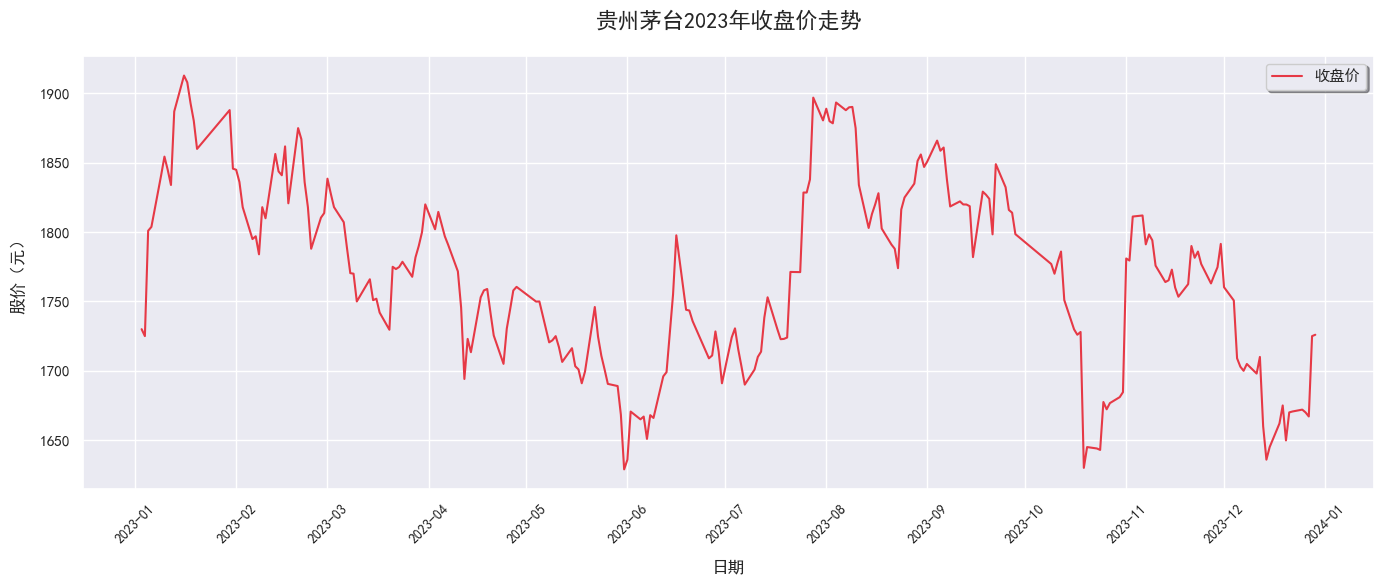

In [14]:
# 1. 基础样式设置（解决中文乱码、统一风格）
sns.set_style('darkgrid')  # 深色网格背景（seaborn经典风格）
sns.set_context('notebook', font_scale=1.0)  # 调整字体大小（适配笔记本显示）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号显示正常
plt.rcParams['figure.dpi'] = 100  # 提高图表清晰度

# 2. 读取CSV数据（保留“日期”字段，指定编码避免乱码）
file_path = 'C:/Users/86157/Desktop/茅台2023年股价.csv'
# 假设原CSV表头为：日期,开盘价（元）,最高价（元）,最低价（元）,收盘价（元）,成交量（手）,成交额（万元）
# 读取时保留所有需要的列，后续统一重命名
data = pd.read_csv(
    file_path,
    encoding='utf-8-sig',  # 匹配CSV生成时的编码，避免中文乱码
    usecols=['日期', '开盘价（元）', '最高价（元）', '最低价（元）', '收盘价（元）', '成交量（手）']  # 明确保留“日期”列
)

# 3. 数据预处理（重命名列+日期格式转换+排序）
# 重命名列为英文（方便后续调用，避免中文括号干扰），同时保留“日期”列
data.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
# 将“Date”转为datetime格式（确保X轴按时间顺序排列）
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')  # 显式指定日期格式，避免解析错误
# 按日期升序排序（防止原始数据顺序混乱）
data_sorted = data.sort_values(by='Date').reset_index(drop=True)

# 4. 用seaborn绘制收盘价走势线图
plt.figure(figsize=(14, 6))  # 设置图表大小（宽14，高6，适配时间轴）

# 绘制收盘价线（指定颜色、线宽，增强视觉效果）
sns.lineplot(
    x='Date',  # X轴为处理后的日期字段
    y='Close',  # Y轴为收盘价
    data=data_sorted,
    color='#E63946',  # 红色线条（突出收盘价走势）
    linewidth=1.5,  # 线条加粗，避免过细看不清
    label='收盘价'  # 图例名称
)

# 5. 图表美化（标题、标签、时间轴、图例）
plt.title('贵州茅台2023年收盘价走势', fontsize=16, pad=20, fontweight='bold')  # 标题加粗，增加间距
plt.xlabel('日期', fontsize=12, labelpad=10)  # X轴标签
plt.ylabel('股价（元）', fontsize=12, labelpad=10)  # Y轴标签（补充单位，更清晰）

# 优化X轴日期显示（避免重叠，按“月”显示主要刻度）
ax = plt.gca()  # 获取当前坐标轴
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # 日期格式：年-月
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # 每1个月显示1个刻度
plt.xticks(rotation=45, fontsize=10)  # 旋转刻度标签45度，避免重叠

# 显示图例（放在右上角，不遮挡走势线）
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# 调整布局（防止标签被截断）
plt.tight_layout()

# 可选：保存高清图片（如需保存，取消注释）
# plt.savefig(
#     'C:/Users/86157/Desktop/茅台2023年收盘价走势.png',
#     dpi=300,  # 高清分辨率
#     bbox_inches='tight'  # 确保标签完整保存
# )

# 显示图表
plt.show()

## 箱线图

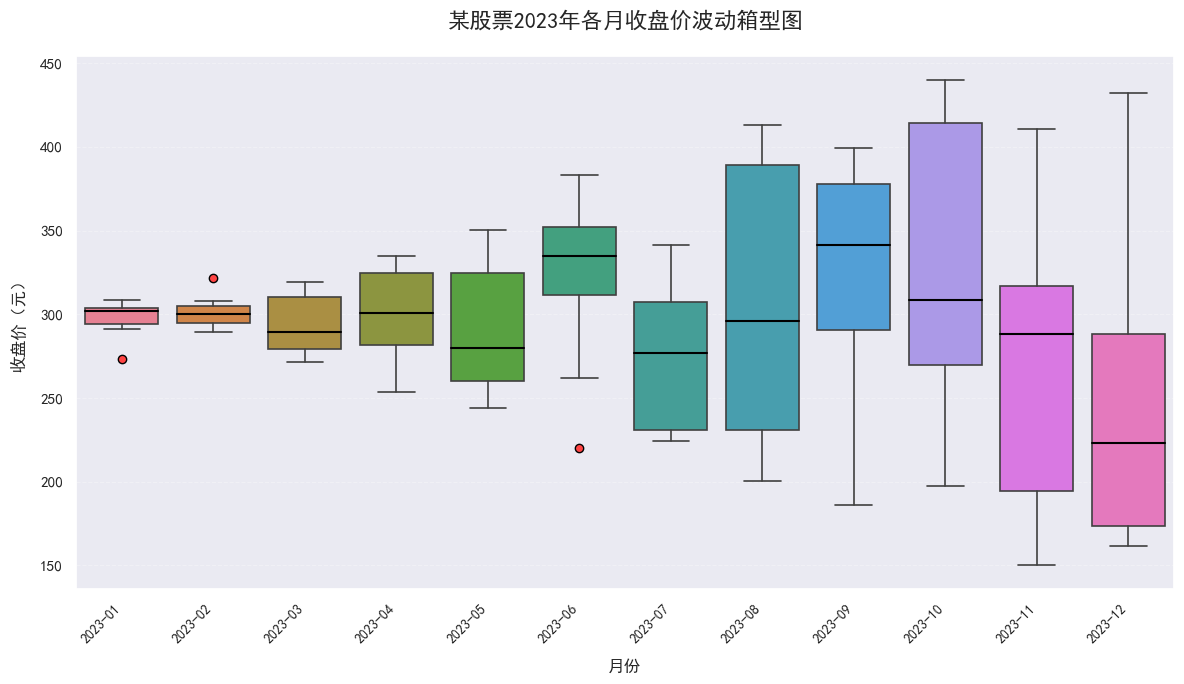

In [20]:
# 1. 导入必需库
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 2. 基础配置（解决中文乱码、提升图表质量）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
plt.rcParams['figure.dpi'] = 100  # 清晰度
plt.rcParams['figure.figsize'] = (12, 7)  # 图表尺寸（宽12，高7）

# 3. 模拟股票数据（2023年1-12月收盘价，含正常波动和异常值）
np.random.seed(42)  # 固定随机种子，确保结果可复现
start_date = datetime(2023, 1, 1)
dates = []
close_prices = []f

# 生成每月数据（1-12月，每月15-20个交易日）
for month in range(1, 13):
    # 确定每月的交易日数量（15-20天，模拟非交易日剔除）
    trade_days = np.random.randint(15, 21)
    # 生成当月日期（跳过周末，简化模拟）
    for day in range(1, trade_days + 1):
        current_date = datetime(2023, month, day)
        # 只保留周一到周五（交易日）
        if current_date.weekday() < 5:
            dates.append(current_date)
            # 模拟收盘价：每月围绕一个中枢波动（1月300元，每月递增/递减5-15元，模拟趋势）
            monthly_center = 300 + np.random.randint(-15, 16) * (month - 1)
            # 每日波动：±3%以内的随机波动
            daily_fluctuation = monthly_center * np.random.uniform(-0.03, 0.03)
            # 加入1%的异常值（模拟突发行情）
            if np.random.random() < 0.01:
                daily_fluctuation += monthly_center * np.random.uniform(-0.1, 0.1)
            # 计算最终收盘价（保留2位小数）
            close_price = round(monthly_center + daily_fluctuation, 2)
            close_prices.append(close_price)

# 4. 构建DataFrame并预处理（提取月份，用于分组）
stock_data = pd.DataFrame({
    'Date': dates,
    'Close': close_prices  # 收盘价
})
# 提取“年-月”作为分组标签（如2023-01、2023-02），作为箱型图X轴
stock_data['Month'] = stock_data['Date'].dt.strftime('%Y-%m')

# 5. 绘制股票价格箱型图
sns.boxplot(
    x='Month',  # X轴：月份（分组维度）
    y='Close',  # Y轴：收盘价（分析对象）
    data=stock_data,
    palette='husl',  # 配色方案（鲜艳且区分度高）
    linewidth=1.2,  # 箱型边框宽度
    flierprops={  # 异常值样式（突出显示）
        'marker': 'o',  # 圆点标记
        'markerfacecolor': '#FF4444',  # 红色填充
        'markeredgecolor': 'black',  # 黑色边框
        'markersize': 6  # 大小
    },
    medianprops={  # 中位数线样式（突出中枢）
        'color': 'black',  # 黑色
        'linewidth': 1.5  # 加粗
    }
)

# 6. 图表美化与信息补充
plt.title('某股票2023年各月收盘价波动箱型图', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('月份', fontsize=12, labelpad=10)
plt.ylabel('收盘价（元）', fontsize=12, labelpad=10)  # 补充单位，信息完整

# 解决X轴月份标签重叠
plt.xticks(rotation=45, ha='right', fontsize=10)  # 旋转45度+右对齐

# 添加网格线（仅Y轴，辅助读取数值）
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# 调整布局，防止标签被截断
plt.tight_layout()

# 显示图表（如需保存，可添加plt.savefig('股票箱型图.png', dpi=300)）
plt.show()

## 小提琴图

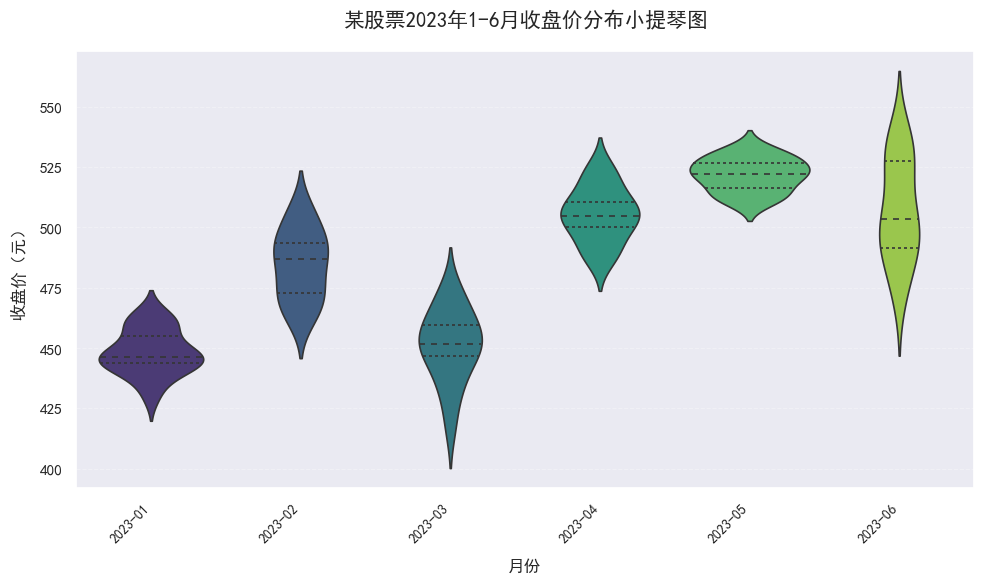

In [21]:
# 1. 导入必需库
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

# 2. 基础配置（解决中文显示、提升图表质量）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
plt.rcParams['figure.dpi'] = 100  # 图表清晰度
plt.rcParams['figure.figsize'] = (10, 6)  # 图表尺寸（宽10，高6）

# 3. 模拟股票数据（2023年1-6月收盘价，含不同月份的分布差异）
np.random.seed(123)  # 固定随机种子，结果可复现
dates = []
close_prices = []

# 为每个月设置不同的价格中枢和波动幅度（模拟真实行情差异）
month_config = {
    1: {'center': 450, 'std': 8},   # 1月：中枢450元，波动小（std=8）
    2: {'center': 480, 'std': 12},  # 2月：中枢480元，波动中等
    3: {'center': 460, 'std': 15},  # 3月：中枢460元，波动大
    4: {'center': 500, 'std': 10},  # 4月：中枢500元，波动中等
    5: {'center': 520, 'std': 7},   # 5月：中枢520元，波动小（价格集中）
    6: {'center': 510, 'std': 18}   # 6月：中枢510元，波动大（价格分散）
}

# 生成每日数据（每月20个交易日，跳过周末）
for month in range(1, 7):
    config = month_config[month]
    # 生成20个交易日的日期（简化：取每月前20个工作日）
    for day in range(1, 21):
        current_date = datetime(2023, month, day)
        if current_date.weekday() < 5:  # 只保留周一到周五（交易日）
            dates.append(current_date)
            # 用正态分布模拟收盘价（更贴近真实价格分布）
            price = np.random.normal(loc=config['center'], scale=config['std'])
            close_prices.append(round(price, 2))  # 保留2位小数

# 4. 构建DataFrame并预处理（提取“年-月”标签，用于分组）
stock_df = pd.DataFrame({
    'Date': dates,
    'Close': close_prices  # 收盘价
})
# 提取月份标签（如“2023-01”），作为小提琴图的X轴
stock_df['Month'] = stock_df['Date'].dt.strftime('%Y-%m')

# 5. 绘制股票价格小提琴图
sns.violinplot(
    x='Month',          # X轴：月份（分组）
    y='Close',          # Y轴：收盘价（分析对象）
    data=stock_df,
    palette='viridis',  # 配色方案（渐变色彩，区分度高）
    inner='quartile',   # 显示四分位线（黑色短线：Q1、中位数、Q3）
    linewidth=1.2,      # 小提琴图边框宽度
    medianprops={       # 中位数标记样式（突出显示）
        'color': 'white',  # 白色圆点
        'marker': 'o',     # 圆点形状
        'markersize': 6    # 圆点大小
    },
    quartileprops={     # 四分位线样式
        'color': 'black',
        'linewidth': 1.5
    }
)

# 6. 图表美化与信息补充
plt.title('某股票2023年1-6月收盘价分布小提琴图', fontsize=15, fontweight='bold', pad=18)
plt.xlabel('月份', fontsize=12, labelpad=10)
plt.ylabel('收盘价（元）', fontsize=12, labelpad=10)  # 补充单位，信息完整

# 解决X轴月份标签重叠
plt.xticks(rotation=45, ha='right', fontsize=10)  # 旋转45度+右对齐

# 添加Y轴网格线（辅助读取数值，不干扰小提琴图）
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# 调整布局，防止标签被截断
plt.tight_layout()

# 可选：保存高清图片（取消注释即可）
# plt.savefig('股票收盘价小提琴图.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

## 关联线图

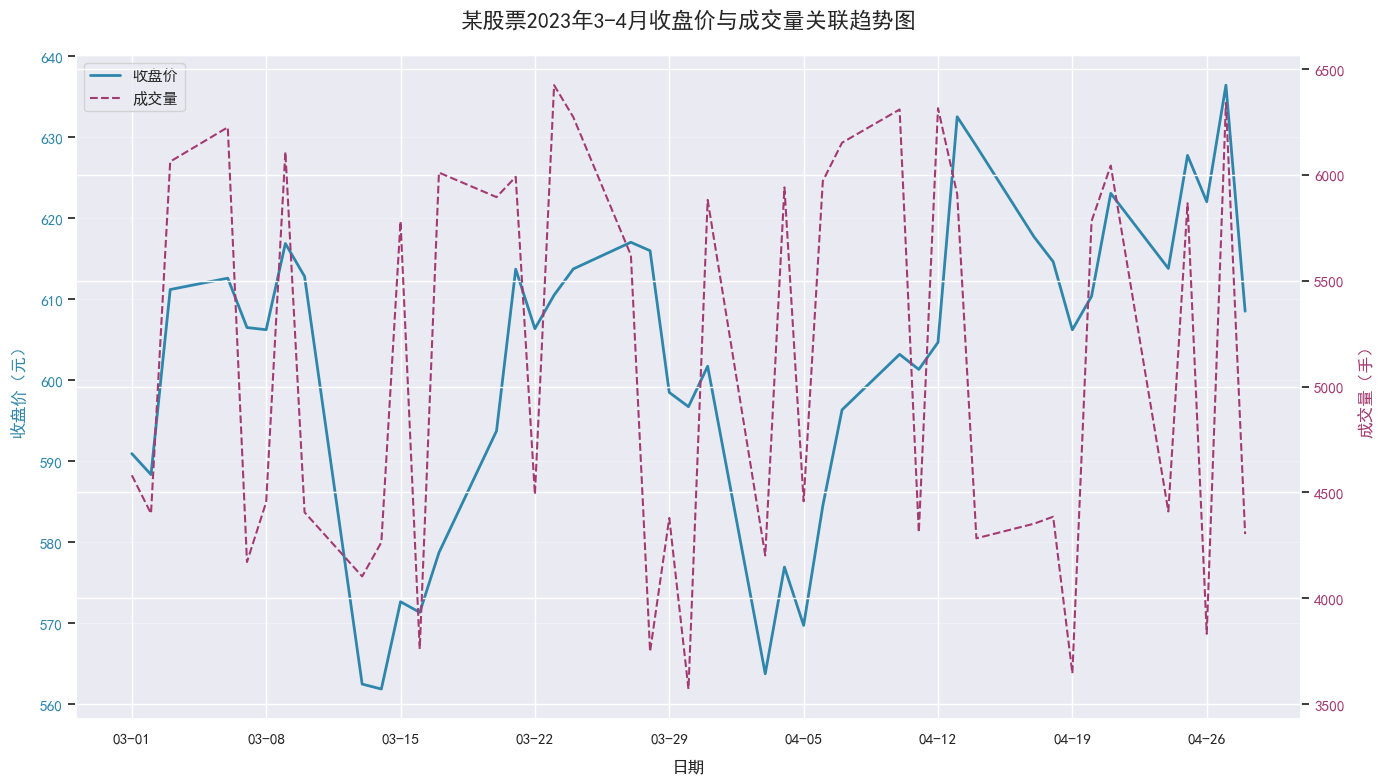

In [22]:
# 1. 导入必需库
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 2. 基础配置（解决中文乱码、提升图表质量）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
plt.rcParams['figure.dpi'] = 100  # 图表清晰度
plt.rcParams['figure.figsize'] = (14, 8)  # 宽14、高8，适配双轴显示

# 3. 模拟股票关联数据（收盘价+成交量，2023年3-4月，共40个交易日）
np.random.seed(456)  # 固定随机种子，结果可复现
dates = []
close_prices = []
volumes = []

# 生成日期（2023年3月1日至4月30日，筛选工作日）
start_date = datetime(2023, 3, 1)
end_date = datetime(2023, 4, 30)
current_date = start_date

while current_date <= end_date:
    if current_date.weekday() < 5:  # 只保留周一到周五（交易日）
        dates.append(current_date)
        current_date += timedelta(days=1)
    else:
        current_date += timedelta(days=1)

# 模拟收盘价（围绕600元波动，带上升趋势，加入短期回调）
base_price = 600
for i in range(len(dates)):
    # 整体上升趋势（每天+0.5元）
    trend = 0.5 * i
    # 随机波动（±3%）
    fluctuation = base_price * np.random.uniform(-0.03, 0.03)
    # 加入2次短期回调（第10天、第25天附近）
    if 8 <= i <= 12 or 23 <= i <= 27:
        fluctuation -= base_price * 0.05  # 回调5%
    close_price = round(base_price + trend + fluctuation, 2)
    close_prices.append(close_price)

# 模拟成交量（与收盘价联动：价格上涨时成交量放大，下跌时缩量）
base_volume = 5000  # 基础成交量（手）
for i in range(len(dates)):
    if i == 0:
        volume = base_volume + np.random.randint(-1000, 1000)
    else:
        # 价格上涨时，成交量增加；价格下跌时，成交量减少（联动逻辑）
        price_change = close_prices[i] - close_prices[i-1]
        volume_fluctuation = np.random.randint(500, 1500) if price_change > 0 else np.random.randint(-1500, -500)
        volume = max(base_volume + volume_fluctuation, 3000)  # 成交量不低于3000手
    volumes.append(volume)

# 4. 构建DataFrame
stock_data = pd.DataFrame({
    'Date': dates,
    'Close': close_prices,  # 收盘价（左轴数据）
    'Volume': volumes       # 成交量（右轴数据）
})

# 5. 绘制双轴关联线图
fig, ax1 = plt.subplots()  # 初始化第一个轴（左轴：收盘价）

# 左轴：绘制收盘价线（主趋势线）
color1 = '#2E86AB'  # 深蓝色
line1 = ax1.plot(
    stock_data['Date'], 
    stock_data['Close'], 
    color=color1, 
    linewidth=2, 
    label='收盘价'
)
ax1.set_xlabel('日期', fontsize=12, labelpad=10)
ax1.set_ylabel('收盘价（元）', color=color1, fontsize=12, labelpad=10)
ax1.tick_params(axis='y', labelcolor=color1)  # 左轴刻度文字颜色与线条一致

# 右轴：创建共享X轴的第二个轴（成交量）
ax2 = ax1.twinx()  # 共享X轴，独立Y轴
color2 = '#A23B72'  # 深粉色
line2 = ax2.plot(
    stock_data['Date'], 
    stock_data['Volume'], 
    color=color2, 
    linewidth=1.5, 
    linestyle='--',  # 虚线区分成交量
    label='成交量'
)
ax2.set_ylabel('成交量（手）', color=color2, fontsize=12, labelpad=10)
ax2.tick_params(axis='y', labelcolor=color2)  # 右轴刻度文字颜色与线条一致

# 6. 优化图表细节（日期显示、图例、网格）
# 优化X轴日期：按周显示，旋转避免重叠
import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))  # 日期格式：月-日
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=7))    # 每7天显示1个刻度（每周）
plt.xticks(rotation=45, fontsize=10)

# 合并双轴图例（左轴+右轴）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

# 添加网格（仅左轴Y轴，不干扰右轴）
ax1.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.8)

# 标题
plt.title('某股票2023年3-4月收盘价与成交量关联趋势图', fontsize=16, fontweight='bold', pad=20)

# 调整布局，防止标签截断
plt.tight_layout()

# 可选：保存图片
# plt.savefig('股票收盘价与成交量关联图.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

Text(0, 0.5, '股票B收益率')

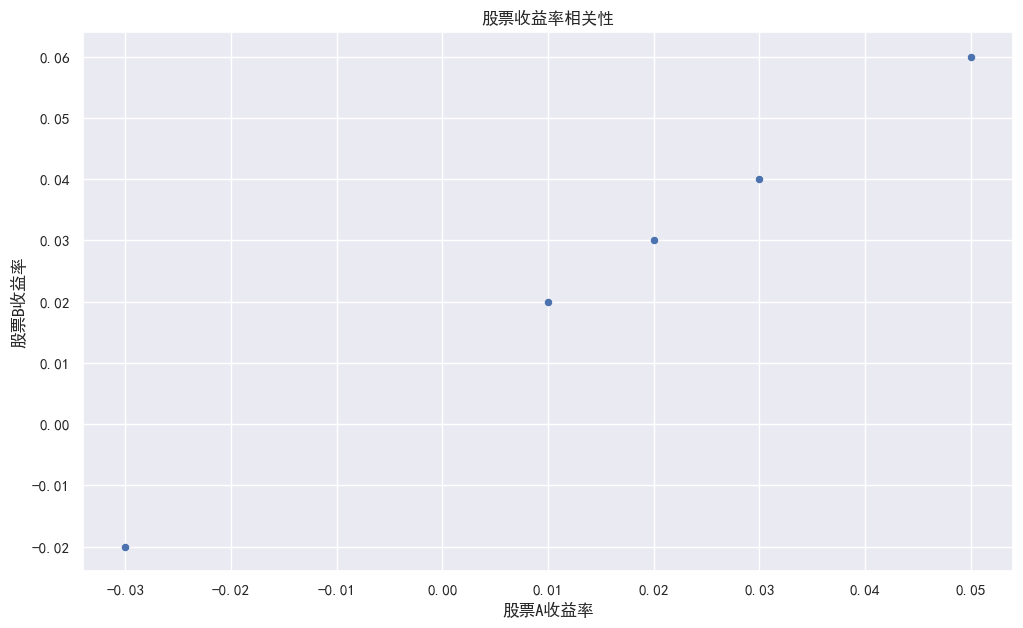

In [29]:
#关联散点图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
#数据
data = pd.DataFrame({'股票A收益率':[0.02,0.05,-0.03,0.01,0.03],
                    '股票B收益率':[0.03,0.06,-0.02,0.02,0.04]})
#设置图表样式
sns.set_style('darkgrid',{'font.sans-serif':['SimHei', 'Arial']})
#绘制关联散点图
sns.scatterplot(x='股票A收益率',y='股票B收益率',data=data)
#添加图表标题和轴标签
plt.title('股票收益率相关性')
plt.xlabel('股票A收益率')
plt.ylabel('股票B收益率')
#显示图片

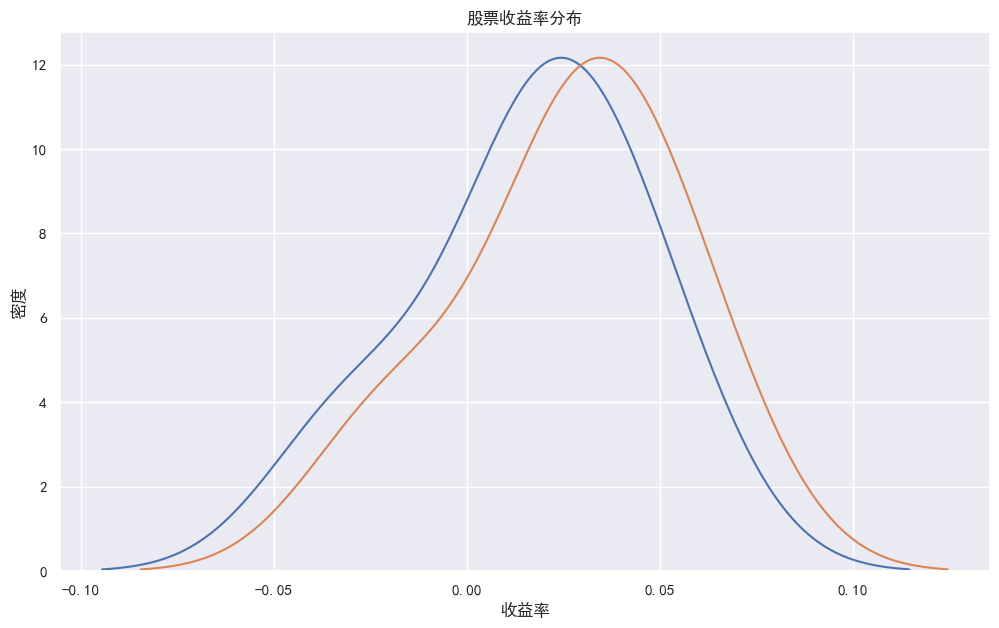

In [32]:
#密度图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 中文支持
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
#数据
data = pd.DataFrame({'股票A收益率':[0.02,0.05,-0.03,0.01,0.03],
                    '股票B收益率':[0.03,0.06,-0.02,0.02,0.04]})
#设置图表样式
sns.set_style('darkgrid',{'font.sans-serif':['SimHei', 'Arial']})
#绘制股票A收益密度图
sns.kdeplot(data['股票A收益率'],label='股票A')
sns.kdeplot(data['股票B收益率'],label='股票B')
#添加图表标题和轴标签
plt.title('股票收益率分布')
plt.xlabel('收益率')
plt.ylabel('密度')
#显示图片
plt.show()

TypeError: __init__() got an unexpected keyword argument 'color'

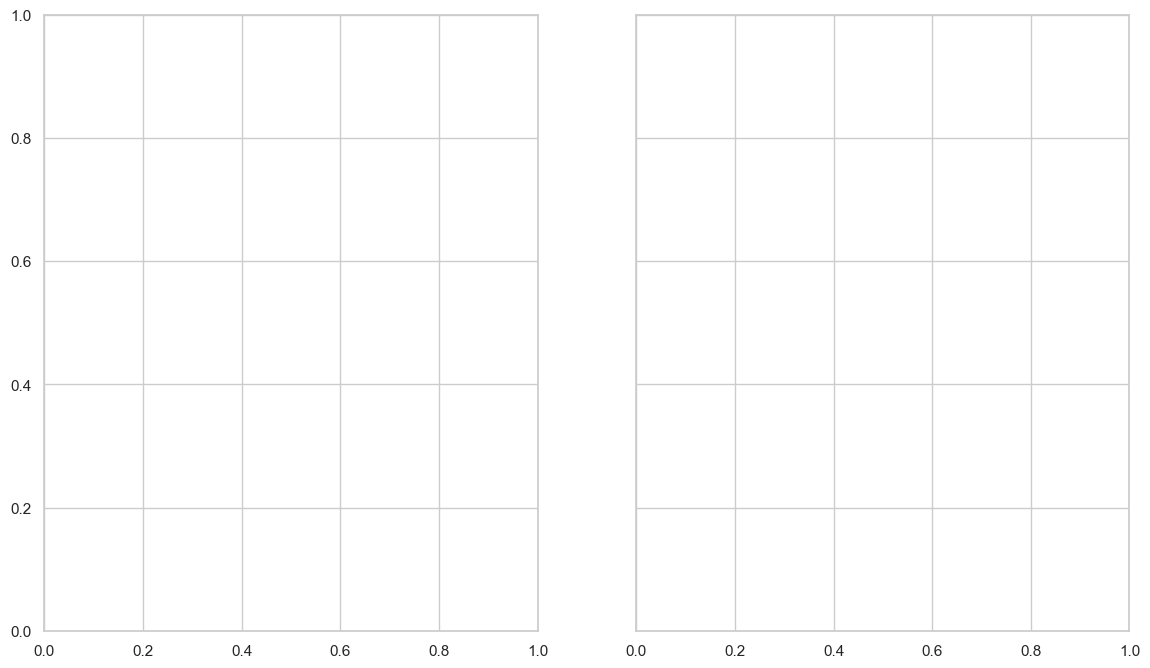

In [34]:
# 1. 导入必需库
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats

# 2. 基础配置（解决中文显示+图表质量）
plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei']  # 中文字体兼容
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示
plt.rcParams['figure.dpi'] = 100  # 清晰度
plt.rcParams['figure.figsize'] = (14, 8)  # 宽14、高8，适配双Dist图

# 3. 模拟真实数据（个股：消费股；大盘：上证指数，体现不同分布特征）
np.random.seed(123)  # 固定随机种子，结果可复现
dates = []

# 步骤1：生成2023年1-10月交易日日期（剔除周末，约200个交易日）
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 10, 31)
current_date = start_date
while current_date <= end_date:
    if current_date.weekday() < 5:  # 仅保留工作日
        dates.append(current_date)
    current_date += timedelta(days=1)

# 步骤2：模拟大盘（上证指数）收益率（低波动、接近正态）
# 大盘特征：日均值0.04%，日标准差1.1%（年化≈17%）
sh_return = np.random.normal(loc=0.04, scale=1.1, size=len(dates))  # 直接生成百分比收益率

# 步骤3：模拟个股（消费股）收益率（低波动、轻微负偏，防御性特征）
# 消费股特征：波动比大盘小，下跌极端值略多（防御性→下跌时更稳，但上涨弹性小）
consume_return = np.random.normal(loc=0.03, scale=0.9, size=len(dates))  # 日标准差0.9%（年化≈14%）
# 加入少量轻微下跌极端值（体现防御性中的“小跌常态”）
minor_drop = np.random.normal(loc=-2.0, scale=0.3, size=5)  # 5个-1.7~-2.3%的小跌值
consume_return[np.random.choice(len(consume_return), 5, replace=False)] = minor_drop

# 步骤4：构建DataFrame，剔除极端异常值（保留99.5%数据，避免图表拉伸）
data = pd.DataFrame({
    'Date': dates,
    '上证指数收益率(%)': sh_return,
    '消费股收益率(%)': consume_return
})
# 按分位数剔除极端值（前后各0.25%）
for col in ['上证指数收益率(%)', '消费股收益率(%)']:
    data = data[(data[col] >= data[col].quantile(0.0025)) & 
                (data[col] <= data[col].quantile(0.9975))]

# 4. 计算关键统计量（用于图表标注，量化分布特征）
# 大盘统计
sh_mean = data['上证指数收益率(%)'].mean()
sh_std = data['上证指数收益率(%)'].std()
sh_median = data['上证指数收益率(%)'].median()

# 消费股统计
consume_mean = data['消费股收益率(%)'].mean()
consume_std = data['消费股收益率(%)'].std()
consume_median = data['消费股收益率(%)'].median()

# 5. 绘制Dist图（子图布局：1行2列，分别展示大盘和消费股）
sns.set_style('whitegrid')  # 白色网格，突出直方图与曲线

# 创建1行2列的子图，共享Y轴（便于对比频次）
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(14, 8))

# ---------------------- 子图1：上证指数收益率Dist图 ----------------------
sns.histplot(
    data=data,
    x='上证指数收益率(%)',
    ax=ax1,
    bins=30,  # 划分30个区间，平衡“细节”与“平滑度”
    kde=True,  # 显示核密度曲线
    color='#2E86AB',  # 深蓝色，大盘风格
    alpha=0.6,  # 直方图透明度
    kde_kws={  # 核密度曲线参数
        'color': 'black',
        'linewidth': 2,
        'label': '核密度曲线'
    },
    label='交易日频次'
)
# 标注均值与中位数（垂直虚线，体现分布中心）
ax1.axvline(x=sh_mean, color='red', linestyle='--', linewidth=1.5, label=f'均值：{sh_mean:.2f}%')
ax1.axvline(x=sh_median, color='orange', linestyle='-.', linewidth=1.5, label=f'中位数：{sh_median:.2f}%')
# 子图1标题与标签
ax1.set_title('上证指数日收益率分布（2023.1-10）', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('日收益率（%）', fontsize=12, labelpad=10)
ax1.set_ylabel('交易日频次', fontsize=12, labelpad=10)
# 图例（位置：左上，不遮挡直方图）
ax1.legend(loc='upper left', fontsize=10)
# 调整X轴范围（聚焦主要收益区间）
ax1.set_xlim(-5, 5)

# ---------------------- 子图2：消费股收益率Dist图 ----------------------
sns.histplot(
    data=data,
    x='消费股收益率(%)',
    ax=ax2,
    bins=30,
    kde=True,
    color='#A23B72',  # 深粉色，消费股风格
    alpha=0.6,
    kde_kws={
        'color': 'black',
        'linewidth': 2,
        'label': '核密度曲线'
    },
    label='交易日频次'
)
# 标注均值与中位数
ax2.axvline(x=consume_mean, color='red', linestyle='--', linewidth=1.5, label=f'均值：{consume_mean:.2f}%')
ax2.axvline(x=consume_median, color='orange', linestyle='-.', linewidth=1.5, label=f'中位数：{consume_median:.2f}%')
# 子图2标题与标签
ax2.set_title('消费股日收益率分布（2023.1-10）', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('日收益率（%）', fontsize=12, labelpad=10)
ax2.set_ylabel('')  # 共享Y轴，右侧子图不重复显示Y标签
# 图例
ax2.legend(loc='upper left', fontsize=10)
# 调整X轴范围（与左侧一致，便于对比）
ax2.set_xlim(-5, 5)

# 6. 全局标题与布局调整
plt.suptitle('股票日收益率分布对比（Dist图）', fontsize=16, fontweight='bold', y=0.98)  # 全局标题
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整布局，避免全局标题与子图标题重叠

# 可选：保存高清图片
# plt.savefig('股票收益率Dist图.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

# 输出统计对比表（量化差异）
print("="*60)
print("2023年1-10月收益率分布统计对比")
print("="*60)
print(f"{'指标':<15} {'上证指数':<15} {'消费股':<15}")
print("-"*60)
print(f"均值（%）{'':<8} {sh_mean:.2f} {'':<10} {consume_mean:.2f}")
print(f"中位数（%）{'':<6} {sh_median:.2f} {'':<10} {consume_median:.2f}")
print(f"波动率（%）{'':<6} {sh_std:.2f} {'':<10} {consume_std:.2f}")
print(f"年化波动率（%）{'':<2} {sh_std*np.sqrt(240):.2f} {'':<10} {consume_std*np.sqrt(240):.2f}")
print("="*60)

C:\Users\86157\.conda\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from c

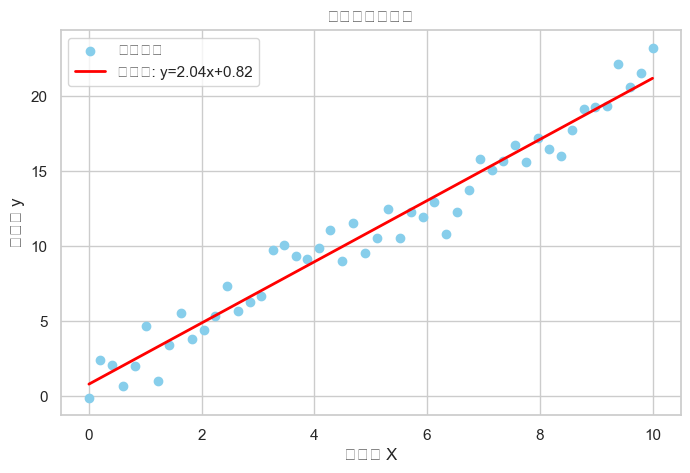

回归系数（斜率）: 2.04
截距: 0.82


In [36]:
# 1. 导入最核心的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 2. 生成最简单的模拟数据（X为自变量，y为因变量，含少量噪声）
np.random.seed(123)  # 固定随机种子，结果可复现
X = np.linspace(0, 10, 50).reshape(-1, 1)  # X: 0-10的50个数据（需转2D数组，符合回归输入要求）
y = 2 * X + 1 + np.random.normal(0, 1, size=X.shape)  # y = 2X + 1 + 噪声（真实回归关系）

# 3. 拟合线性回归模型
model = LinearRegression()
model.fit(X, y)  # 训练模型
y_pred = model.predict(X)  # 用模型预测y值（回归线的y坐标）

# 4. 绘制极简线性回归图（散点+回归线）
plt.figure(figsize=(8, 5))  # 图表大小

# 画原始数据散点
plt.scatter(X, y, color='skyblue', label='原始数据')
# 画回归线
plt.plot(X, y_pred, color='red', linewidth=2, label=f'回归线: y={model.coef_[0][0]:.2f}x+{model.intercept_[0]:.2f}')

# 简单标注（标题、轴标签、图例）
plt.title('极简线性回归图')
plt.xlabel('自变量 X')
plt.ylabel('因变量 y')
plt.legend()  # 显示图例

# 显示图表
plt.show()

# 输出核心回归参数（可选）
print(f'回归系数（斜率）: {model.coef_[0][0]:.2f}')  # 理论值为2，实际因噪声略有偏差
print(f'截距: {model.intercept_[0]:.2f}')  # 理论值为1，实际因噪声略有偏差

C:\Users\86157\.conda\envs\ml-env\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from current font.
  fig.canvas.draw()
C:\Users\86157\.conda\envs\ml-env\lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from current font.
  fig.canvas.draw()
C:\Users\86157\AppData\Local\Temp\ipykernel_9136\3040787117.py:58: UserWarning: Glyph 21482 (\N{CJK UNIFIED IDEOGRAPH-53EA}) missing from current font.
  plt.tight_layout()  # 调整布局，防止标签截断
C:\Users\86157\AppData\Local\Temp\ipykernel_9136\3040787117.py:58: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from current font.
  plt.tight_layout()  # 调整布局，防止标签截断
C:\Users\86157\AppData\Local\Temp\ipykernel_9136\3040787117.py:58: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from current font.
  plt.tight_layout()  # 调整布局，防止标签截断
C:\Users\86157\AppData\Local\Temp\ipykernel_9136\3040787117.py:58: UserWarning: 

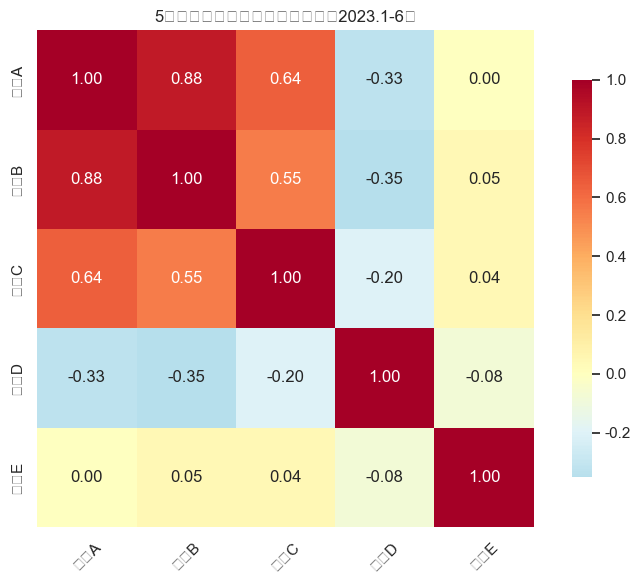

In [37]:
# 1. 导入核心库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 2. 生成模拟股票数据（5只股票，2023年1-6月交易日）
np.random.seed(123)  # 固定随机种子，结果可复现
stock_names = ['股票A', '股票B', '股票C', '股票D', '股票E']  # 5只股票名称
dates = []

# 步骤1：生成交易日日期（2023年1-6月，剔除周末，约120天）
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 6, 30)
current_date = start_date
while current_date <= end_date:
    if current_date.weekday() < 5:  # 只保留周一到周五
        dates.append(current_date)
    current_date += timedelta(days=1)

# 步骤2：模拟股票收盘价（基于随机游走，带不同相关性）
# 股票A：基础走势；B/C与A正相关；D与A弱负相关；E独立波动
n_days = len(dates)
base_trend = np.cumsum(np.random.normal(0.001, 0.02, n_days))  # 基础趋势（小幅上涨）

stock_data = pd.DataFrame(index=dates)
stock_data['股票A'] = 10 + base_trend  # 股票A：基础趋势
stock_data['股票B'] = 15 + base_trend + np.random.normal(0, 0.01, n_days)  # 与A强正相关
stock_data['股票C'] = 20 + base_trend * 0.8 + np.random.normal(0, 0.015, n_days)  # 与A中强正相关
stock_data['股票D'] = 25 - base_trend * 0.3 + np.random.normal(0, 0.02, n_days)  # 与A弱负相关
stock_data['股票E'] = 30 + np.cumsum(np.random.normal(0, 0.02, n_days))  # 独立波动（与A低相关）

# 3. 计算股票日收益率（相关性基于收益率，而非收盘价）
returns = stock_data.pct_change() * 100  # 日收益率（百分比）
returns = returns.dropna()  # 删除首日NaN数据

# 4. 计算相关系数矩阵（核心：Pearson相关系数，-1~1之间）
corr_matrix = returns.corr()

# 5. 绘制极简相关性热力图
plt.figure(figsize=(8, 6))  # 图表大小

# 核心：绘制热力图
sns.heatmap(
    corr_matrix,  # 相关系数矩阵
    annot=True,  # 显示相关系数数值
    cmap='RdYlBu_r',  # 颜色映射（红=负相关，黄=无相关，蓝=正相关）
    center=0,  # 颜色中心值（0=无相关）
    square=True,  # 热力图格子为正方形
    fmt='.2f',  # 数值保留2位小数
    cbar_kws={'shrink': 0.8}  # 颜色条缩放比例
)

# 简单标注（标题、调整字体）
plt.title('5只股票日收益率相关性热力图（2023.1-6）', fontsize=12)
plt.xticks(rotation=45)  # X轴股票名旋转45度，避免重叠
plt.tight_layout()  # 调整布局，防止标签截断

# 显示图表
plt.show()